
# Analiza e Hotel Booking Demand Dataset

**Tema:** Analiza e rezervimeve te hoteleve dhe faktoreve qe ndikojne ne anulime.

**Dataset:** Hotel Booking Demand  
**Burimi i të dhenave:** Kaggle / TidyTuesday mirror  
**Forma:** CSV  
**Madhesia origjinale:** 119,390 rekorde dhe 32 kolona.


## 1. Importimi i librarive dhe leximi i dataset-it

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Leximi lokalisht i file
df = pd.read_csv("~/detyre_kursi/Datasets/hotel_bookings.csv")

print('Forma e dataset-it:', df.shape)
df.head()

Forma e dataset-it: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Eksplorimi fillestar i te dhenave

In [7]:
df.info()
print('Kolonat:')
print(df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

**Informacione te vlefshme:**

**Kolonat**: Dataset ka 32 kolona.

**Data-types**: 

**12** nga kolonat permbajne variabla kategorike te paraitura si string.

**16** nga kolonat permbajne te dhena te tipit integer

**4** nga kolona permbajne te dhena te tipit float


In [ ]:
# Missing values per cdo kolone
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

company     112593
agent        16340
country        488
children         4
dtype: int64


## 3. Pastrimi i te dhenave

Vendimmarrja per missing values:

- `children`: ka shume pak vlera bosh, duke marre parasysh numrin e rekordeve ne dataset, 4 missing values te kolones children do te vendosen ne 0.
- `country`: zevendesohet me `Unknown`, edhe pse ne mungese te shtetit rekorded me missing values jane me vlere dhe te shumta ne numer. 
- `agent` dhe `company`: zevendesohen me 0, sepse mungesa tregon qe rezervimi nuk eshte bere nga nje agjent/kompani e regjistruar.
- Rreshtat ku `adults + children + babies = 0` hiqen, sepse nuk perfaqesojne nje rezervim kuptimplote: "Rezervim per 0 persona".


In [10]:
hotel_df = df.copy()

hotel_df['children'] = hotel_df['children'].fillna(0).astype(int)
hotel_df['country'] = hotel_df['country'].fillna('Unknown')
hotel_df['agent'] = hotel_df['agent'].fillna(0).astype(int)
hotel_df['company'] = hotel_df['company'].fillna(0).astype(int)
hotel_df['reservation_status_date'] = pd.to_datetime(hotel_df['reservation_status_date'])

# Heqim rezervimet pa asnje klient
hotel_df = hotel_df[(hotel_df['adults'] + hotel_df['children'] + hotel_df['babies']) > 0].copy()

# Krijojme kolona te reja per analize
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
hotel_df['arrival_date_month'] = pd.Categorical(hotel_df['arrival_date_month'], categories=month_order, ordered=True)
hotel_df['arrival_date'] = pd.to_datetime(
    hotel_df['arrival_date_year'].astype(str) + '-' +
    hotel_df['arrival_date_month'].astype(str) + '-' +
    hotel_df['arrival_date_day_of_month'].astype(str),
    errors='coerce'
)
hotel_df['total_nights'] = hotel_df['stays_in_weekend_nights'] + hotel_df['stays_in_week_nights']
hotel_df['total_guests'] = hotel_df['adults'] + hotel_df['children'] + hotel_df['babies']
hotel_df['estimated_revenue'] = np.where(hotel_df['is_canceled'] == 0, hotel_df['adr'] * hotel_df['total_nights'], 0)

print('Forma pas pastrimit:', hotel_df.shape)
hotel_df.head()

df.to_csv("~/detyre_kursi/Datasets/preprocessed_hotel_bookings.csv", index=False)

Forma pas pastrimit: (119210, 36)



## Pyetjet analitike

4. Cili tip hoteli dhe cili tip klienti kanë normën më të lartë të anulimeve?
5. Si ndryshojnë rezervimet dhe anulimet sipas muajve?
6. Si lidhen `lead_time` dhe `adr` me probabilitetin e anulimit?
7. Nga cilat shtete vijnë më shumë klientë dhe cili segment tregu sjell më shumë të ardhura të vlerësuara?

## 4. Pyetja 1: Cili tip hoteli dhe klienti kane me shume anullime?

In [6]:
cancel_pivot = hotel_df.pivot_table(
    values='is_canceled',
    index='customer_type',
    columns='hotel',
    aggfunc='mean',
    observed=False
) * 100

cancel_pivot

hotel,City Hotel,Resort Hotel
customer_type,,
Contract,48.127178,8.840090
Group,9.965636,10.247350
Transient,45.685990,31.171368
Transient-Party,28.120666,19.514388


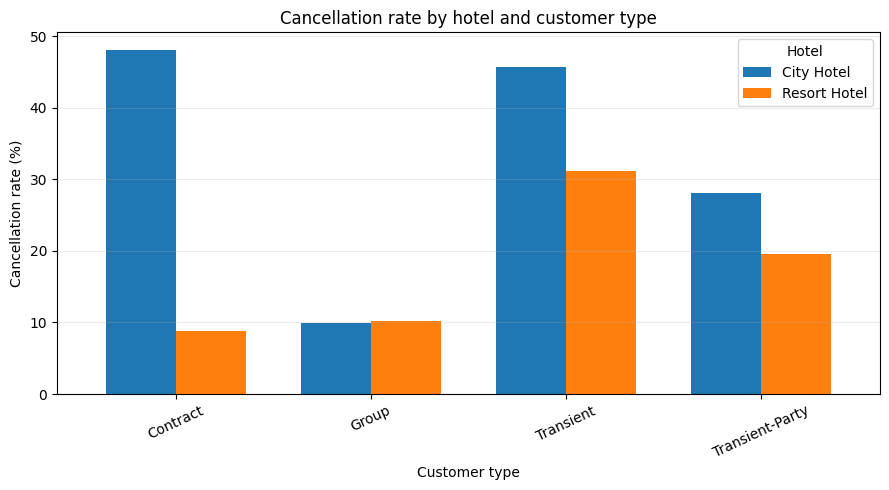

In [7]:
ax = cancel_pivot.plot(kind='bar', figsize=(9, 5), width=0.72)
plt.title('Cancellation rate by hotel and customer type')
plt.ylabel('Cancellation rate (%)')
plt.xlabel('Customer type')
plt.xticks(rotation=25)
plt.grid(axis='y', alpha=0.25)
plt.legend(title='Hotel')
plt.tight_layout()
plt.savefig('chart1_cancel_hotel_customer.png', dpi=200)
plt.show()

## 5. Pyetja 2: Si ndryshojne rezervimet dhe anulimet sipas muajve?

In [8]:
monthly_bookings = hotel_df.groupby('arrival_date_month', observed=False).size()
monthly_cancel_rate = hotel_df.groupby('arrival_date_month', observed=False)['is_canceled'].mean() * 100

pd.DataFrame({
    'bookings': monthly_bookings,
    'cancellation_rate_%': monthly_cancel_rate.round(2)
})

,bookings,cancellation_rate_%
arrival_date_month,,
January,5921,30.50
February,8052,33.45
March,9768,32.23
April,11078,40.78
May,11780,39.70
June,10929,41.49
July,12644,37.46
August,13861,37.78
September,10500,39.19


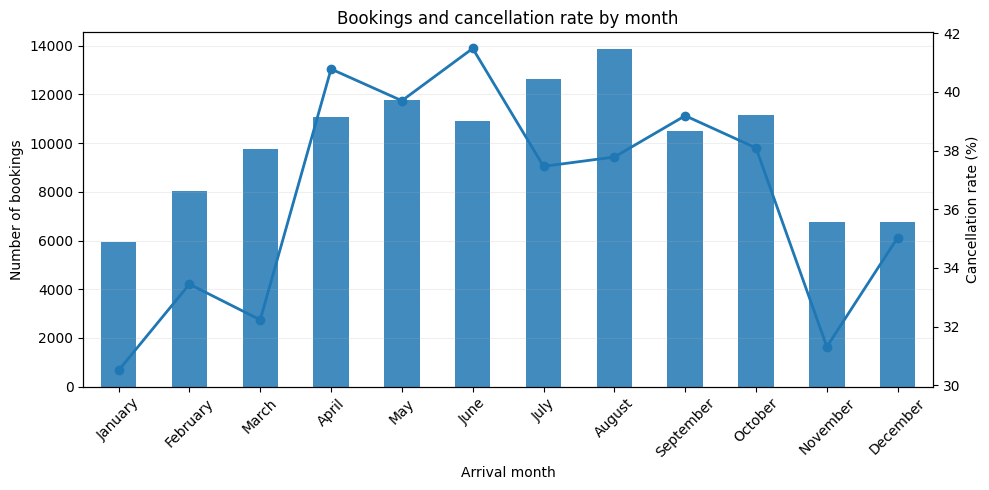

In [9]:
fig, ax1 = plt.subplots(figsize=(10, 5))
monthly_bookings.plot(kind='bar', ax=ax1, alpha=0.85)
ax1.set_title('Bookings and cancellation rate by month')
ax1.set_ylabel('Number of bookings')
ax1.set_xlabel('Arrival month')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.2)

ax2 = ax1.twinx()
ax2.plot(range(len(month_order)), monthly_cancel_rate.loc[month_order], marker='o', linewidth=2)
ax2.set_ylabel('Cancellation rate (%)')

plt.tight_layout()
plt.savefig('chart2_month_bookings_cancel.png', dpi=200)
plt.show()

## 6. Pyetja 3: Si lidhen `lead_time` dhe `adr` me anulimin?

In [10]:
lead_bins = [0, 7, 30, 90, 180, 365, hotel_df['lead_time'].max()+1]
lead_labels = ['0-7','8-30','31-90','91-180','181-365','365+']
hotel_df['lead_time_group'] = pd.cut(hotel_df['lead_time'], bins=lead_bins, labels=lead_labels, include_lowest=True)

price_df = hotel_df[(hotel_df['adr'] >= 0) & (hotel_df['adr'] <= 500)].copy()
price_bins = [0, 50, 100, 150, 200, 500]
price_labels = ['0-50','51-100','101-150','151-200','200+']
price_df['adr_group'] = pd.cut(price_df['adr'], bins=price_bins, labels=price_labels, include_lowest=True)

heatmap_data = price_df.pivot_table(
    values='is_canceled',
    index='lead_time_group',
    columns='adr_group',
    aggfunc='mean',
    observed=False
) * 100

heatmap_data.round(1)

adr_group,0-50,51-100,101-150,151-200,200+
lead_time_group,,,,,
0-7,6.7,9.9,11.0,12.1,10.5
8-30,15.4,26.1,31.9,31.0,36.5
31-90,29.5,35.9,40.9,40.3,41.6
91-180,33.8,42.5,47.0,50.8,47.5
181-365,50.9,57.3,53.8,52.9,50.5
365+,39.5,88.0,6.2,85.7,50.0


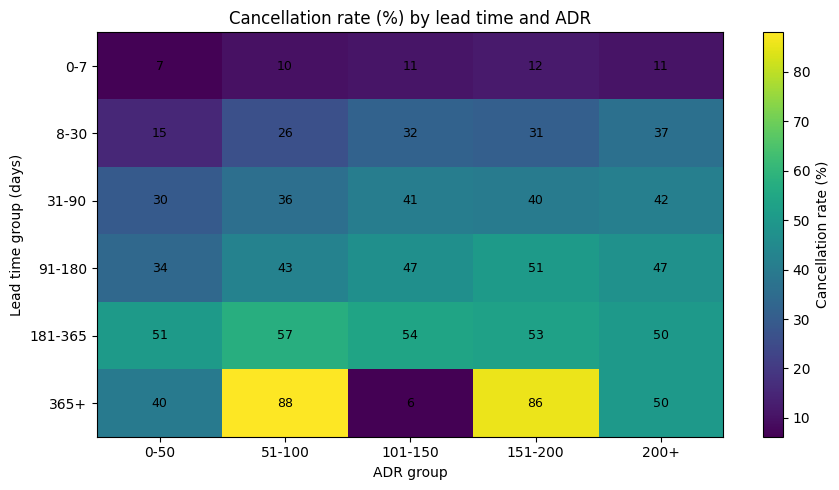

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(heatmap_data.values, aspect='auto')
ax.set_title('Cancellation rate (%) by lead time and ADR')
ax.set_xticks(np.arange(len(price_labels)))
ax.set_yticks(np.arange(len(lead_labels)))
ax.set_xticklabels(price_labels)
ax.set_yticklabels(lead_labels)
ax.set_xlabel('ADR group')
ax.set_ylabel('Lead time group (days)')

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.values[i, j]
        if not np.isnan(value):
            ax.text(j, i, f'{value:.0f}', ha='center', va='center', fontsize=9)

plt.colorbar(im, ax=ax, label='Cancellation rate (%)')
plt.tight_layout()
plt.savefig('chart3_heat_lead_adr.png', dpi=200)
plt.show()

## 7. Pyetja 4: Nga cilat shtete vijne me shume kliente dhe cilat segmente sjellin me shume te ardhura?

In [12]:
completed = hotel_df[hotel_df['is_canceled'] == 0]

top_countries = completed.groupby('country').agg(
    bookings=('country', 'size'),
    revenue=('estimated_revenue', 'sum')
).sort_values('bookings', ascending=False).head(10)

top_countries

,bookings,revenue
country,,
PRT,20977,5540431.72
GBR,9668,4110832.81
FRA,8468,3098418.27
ESP,6383,2246305.29
DEU,6067,2068219.65
IRL,2542,1240002.35
ITA,2428,866439.42
BEL,1868,759145.06
NLD,1716,631636.11


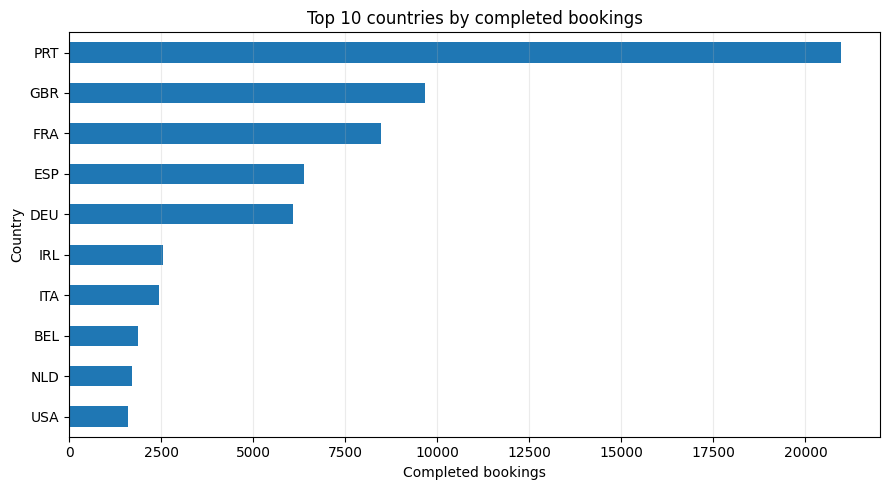

In [13]:
ax = top_countries['bookings'].sort_values().plot(kind='barh', figsize=(9, 5))
plt.title('Top 10 countries by completed bookings')
plt.xlabel('Completed bookings')
plt.ylabel('Country')
plt.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.savefig('chart4_top_countries.png', dpi=200)
plt.show()

In [14]:
market_revenue = completed.groupby('market_segment').agg(
    bookings=('hotel', 'size'),
    revenue=('estimated_revenue', 'sum')
).sort_values('revenue', ascending=False)

market_revenue

,bookings,revenue
market_segment,,
Online TA,35673,13707139.09
Offline TA/TO,15880,5659291.94
Direct,10648,4097842.40
Groups,7697,1869065.72
Corporate,4291,577892.19
Aviation,183,70868.36
Complementary,639,4812.53


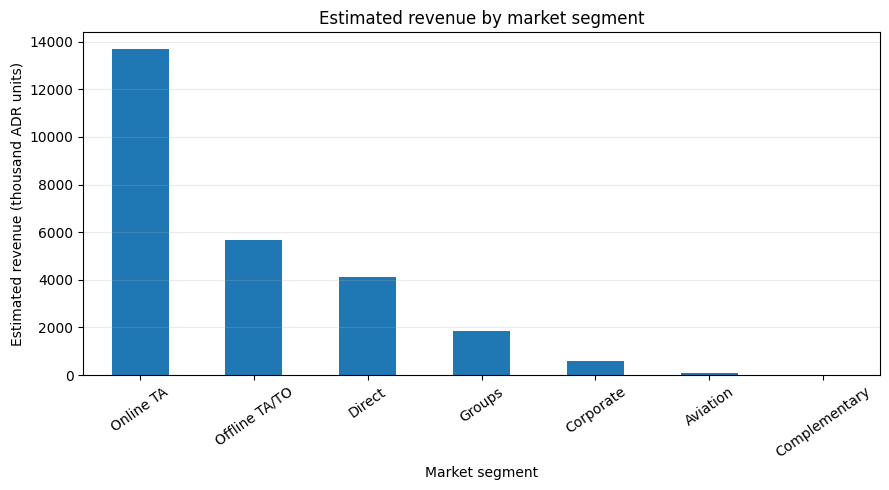

In [15]:
ax = (market_revenue['revenue'] / 1000).plot(kind='bar', figsize=(9, 5))
plt.title('Estimated revenue by market segment')
plt.ylabel('Estimated revenue (thousand ADR units)')
plt.xlabel('Market segment')
plt.xticks(rotation=35)
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig('chart5_market_revenue.png', dpi=200)
plt.show()


## 8. Perfundime per posterin

- Dataset-i ka **119,390 rekorde** dhe **32 kolona**.
- Pas pastrimit mbeten **119,210 rekorde** te vlefshme.
- Norma me e larte e anulimit sipas hotelit eshte te **City Hotel**, me rreth **41.8%**.
- Muaji me me shume rezervime eshte **August**.
- Klientet me `lead_time` me te gjate kane pergjithesisht norme me te larte anulimi.
- Shteti me me shume rezervime te perfunduara eshte **PRT**.

## Referenca

- Hotel Booking Demand Dataset - Kaggle / TidyTuesday mirror.
- Python libraries: pandas, numpy, matplotlib.
